# FineBio — View Selection + Lightweight Triangulation
Takes YOLO26 detections from all 6 cameras, selects the best unoccluded view per object per frame, then triangulates approximate 3D positions using the shipped calibration files.

## 1. Install dependencies

In [1]:
!pip install opencv-python numpy matplotlib tqdm ultralytics -q

## 2. Config

In [9]:
from pathlib import Path

# --- Set these ---
FINEBIO_ROOT   = Path("/home/nyan/FineBio")
CAL_ROOT       = FINEBIO_ROOT / "14 misc/finebio_camera_poses/finebio_camera_poses"
YOLO_WEIGHTS   = Path("runs/detect/runs/finebio_yolo26/yolo26n_joint3/weights/best.pt")  # from notebook 1

# Example trial to run — change to any valid participant/date/trial
TRIAL_DATE     = "221207"          # yymmdd folder under third_person_camera_poses
PARTICIPANT    = "P01"             # used to load first-person pose
TRIAL_ID       = "P01_01_01"       # matches first_person_camera_poses/<id>.npz

# Camera IDs for third-person views (1–5 in FineBio)
TP_CAM_IDS     = [1, 2, 3, 4, 5]

# Confidence threshold for YOLO detections
CONF_THRESH    = 0.3

# Hand class names as they appear in your YOLO training (adjust if different)
HAND_CLASSES   = ["left_hand", "right_hand", "hand"]

print("Config set.")

Config set.


## 3. Camera calibration loader
Wraps all .npz files into a unified per-camera dict with K, dist, R, t.

In [ ]:
import numpy as np
import cv2

def load_intrinsics(npz_path):
    """Load K and distortion coefficients from a FineBio intrinsics .npz."""
    data = np.load(npz_path)
    print(f"Intrinsics keys: {list(data.files)}")

    # FineBio intrinsics use keys ['distCoeff', 'intrinsic_matrix', 'newMat']
    # Map them explicitly instead of relying on ordering.
    if "intrinsic_matrix" in data.files:
        K = data["intrinsic_matrix"]
    else:
        K = data[data.files[0]]

    if "distCoeff" in data.files:
        dist = data["distCoeff"]
    elif "dist_coeffs" in data.files:
        dist = data["dist_coeffs"]
    else:
        # Fall back to a zero-distortion model if coefficients are missing
        print("  Warning: no explicit distCoeff/dist_coeffs; assuming zero distortion")
        dist = np.zeros((1, 5), dtype=np.float64)

    return K.astype(np.float64), dist.astype(np.float64)


def load_extrinsics(npz_path):
    """Load R, t from a FineBio extrinsics .npz (rvec/tvec convention)."""
    data = np.load(npz_path)
    print(f"Extrinsics keys ({npz_path.name}): {list(data.files)}")
    rvec = data["rvec"] if "rvec" in data.files else data[data.files[0]]
    tvec = data["tvec"] if "tvec" in data.files else data[data.files[1]]
    R, _ = cv2.Rodrigues(rvec.reshape(3, 1))
    t    = tvec.reshape(3, 1)
    return R.astype(np.float64), t.astype(np.float64)


def build_projection_matrix(K, R, t):
    """P = K @ [R | t]  (3x4)"""
    Rt = np.hstack([R, t])
    return (K @ Rt).astype(np.float64)


def load_all_cameras(cal_root, trial_date, trial_id, tp_cam_ids):
    """
    Returns a dict: cam_id -> {"K", "dist", "R", "t", "P", "type"}
    cam_id: 1-5 for third-person, "fp" for first-person
    """
    cameras = {}

    # Intrinsics paths
    intr_tp_path = cal_root / "intrinsic_parameters" / "gopro9_6_linear_4k_169_0.50.npz"
    intr_fp_path = cal_root / "intrinsic_parameters" / "gopro9_5_wide_4k_43_0.50.npz"

    K_tp, dist_tp = load_intrinsics(intr_tp_path)
    K_fp, dist_fp = load_intrinsics(intr_fp_path)

    # Third-person cameras
    for cam_id in tp_cam_ids:
        ext_path = cal_root / "third_person_camera_poses" / trial_date / "extrinsics" / f"{cam_id}_board.npz"
        if not ext_path.exists():
            print(f"  Warning: extrinsics not found for cam {cam_id} — {ext_path}")
            continue
        R, t = load_extrinsics(ext_path)
        cameras[cam_id] = {
            "K": K_tp, "dist": dist_tp,
            "R": R, "t": t,
            "P": build_projection_matrix(K_tp, R, t),
            "type": "third_person",
        }

    # First-person camera
    fp_path = cal_root / "first_person_camera_poses" / f"{trial_id}.npz"
    if fp_path.exists():
        fp_data = np.load(fp_path)
        print(f"First-person pose keys: {list(fp_data.files)}")
        # First-person pose is per-frame — we store all frames and index at runtime
        cameras["fp"] = {
            "K": K_fp, "dist": dist_fp,
            "poses": fp_data,   # raw npz — indexed per frame below
            "type": "first_person",
        }
    else:
        print(f"  Warning: first-person pose not found — {fp_path}")

    print(f"\nLoaded {len(cameras)} cameras: {list(cameras.keys())}")
    return cameras


cameras = load_all_cameras(CAL_ROOT, TRIAL_DATE, TRIAL_ID, TP_CAM_IDS)

# Inspect a camera to verify shapes
cam1 = cameras[1]
print(f"\nCam 1 — K shape: {cam1['K'].shape}, R: {cam1['R'].shape}, t: {cam1['t'].shape}, P: {cam1['P'].shape}")

Intrinsics keys: ['distCoeff', 'intrinsic_matrix', 'newMat']
Intrinsics keys: ['distCoeff', 'intrinsic_matrix', 'newMat']
Extrinsics keys (1_board.npz): ['r', 't']
Extrinsics keys (2_board.npz): ['r', 't']
Extrinsics keys (3_board.npz): ['r', 't']
Extrinsics keys (4_board.npz): ['r', 't']
First-person pose keys: ['rets', 'rots', 'trans']

Loaded 5 cameras: [1, 2, 3, 4, 'fp']

Cam 1 — K shape: (3, 3), R: (3, 3), t: (3, 1), P: (3, 4)


## 4. YOLO26 detection across all views for a single frame
Run the fine-tuned detector on all 6 camera images for the same timestamp.

In [12]:
from ultralytics import YOLO
import json

model = YOLO(str(YOLO_WEIGHTS))
cat_names = model.names  # {0: 'class_name', ...}

# Hand class indices (for occlusion scoring)
hand_cls_ids = {k for k, v in cat_names.items() if v.lower() in HAND_CLASSES}
print(f"Hand class indices: {hand_cls_ids}")


def detect_frame(img_path, model, conf=CONF_THRESH):
    """
    Run YOLO on one frame. Returns list of dicts:
      {cls_id, cls_name, conf, bbox_xyxy, bbox_center}
    """
    result = model(img_path, conf=conf, verbose=False)[0]
    detections = []
    for box in result.boxes:
        x1, y1, x2, y2 = box.xyxy[0].tolist()
        cls_id = int(box.cls[0])
        detections.append({
            "cls_id"     : cls_id,
            "cls_name"   : cat_names[cls_id],
            "conf"       : float(box.conf[0]),
            "bbox_xyxy"  : [x1, y1, x2, y2],
            "bbox_center": [(x1 + x2) / 2, (y1 + y2) / 2],
        })
    return detections


def detect_all_views(frame_paths_dict, model):
    """
    frame_paths_dict: {cam_id: Path to image for this timestamp}
    Returns: {cam_id: [detections]}
    """
    all_detections = {}
    for cam_id, img_path in frame_paths_dict.items():
        all_detections[cam_id] = detect_frame(img_path, model)
        print(f"  Cam {cam_id}: {len(all_detections[cam_id])} detections")
    return all_detections


# --- Demo: use real FineBio object-detection images that exist on disk ---
demo_img_root = Path("/home/nyan/FineBio/12 finebio_object_detection_images/finebio_object_detection_images")

# For now we just pick 6 real images; they are not truly time-synchronised,
# but they are enough to exercise the view-selection + triangulation code.
demo_frame_paths = {
    1   : demo_img_root / "P01_01_01_000152.jpg",
    2   : demo_img_root / "P01_01_01_000983.jpg",
    3   : demo_img_root / "P01_01_01_001808.jpg",
    4   : demo_img_root / "P01_01_01_003461.jpg",
    5   : demo_img_root / "P01_01_02_000406.jpg",
    "fp": demo_img_root / "P01_01_02_001325.jpg",
}

all_detections = detect_all_views(demo_frame_paths, model)

Hand class indices: {0, 1}
  Cam 1: 22 detections
  Cam 2: 15 detections
  Cam 3: 23 detections
  Cam 4: 6 detections
  Cam 5: 13 detections
  Cam fp: 18 detections


## 5. View selection — best unoccluded view per object
Scores each detection by confidence and distance from hand bboxes (occlusion proxy).

In [13]:
import numpy as np

def bbox_iou(a, b):
    """IoU between two [x1,y1,x2,y2] boxes."""
    ix1 = max(a[0], b[0]); iy1 = max(a[1], b[1])
    ix2 = min(a[2], b[2]); iy2 = min(a[3], b[3])
    inter = max(0, ix2 - ix1) * max(0, iy2 - iy1)
    area_a = (a[2]-a[0]) * (a[3]-a[1])
    area_b = (b[2]-b[0]) * (b[3]-b[1])
    union  = area_a + area_b - inter
    return inter / union if union > 0 else 0.0


def occlusion_score(det, hand_dets):
    """
    Returns 1.0 if no overlap with any hand, lower if occluded.
    Uses max IoU with any hand bbox as the occlusion penalty.
    """
    if not hand_dets:
        return 1.0
    max_iou = max(bbox_iou(det["bbox_xyxy"], h["bbox_xyxy"]) for h in hand_dets)
    return 1.0 - max_iou


def select_best_views(all_detections, hand_cls_ids, conf_weight=0.5, occl_weight=0.5):
    """
    For each class, find the best (cam_id, detection) pair across all views.
    Score = conf_weight * conf + occl_weight * occlusion_score

    Returns: {
        cls_id: {
            "best_cam"  : cam_id,
            "detection" : det_dict,
            "score"     : float,
            "all_views" : [(cam_id, det, score), ...]
        }
    }
    """
    # Gather candidates per class across all views
    candidates = {}   # cls_id -> [(cam_id, det, score)]

    for cam_id, dets in all_detections.items():
        hand_dets = [d for d in dets if d["cls_id"] in hand_cls_ids]
        for det in dets:
            if det["cls_id"] in hand_cls_ids:
                continue   # skip hands — we use MediaPipe for those
            occ   = occlusion_score(det, hand_dets)
            score = conf_weight * det["conf"] + occl_weight * occ
            candidates.setdefault(det["cls_id"], []).append((cam_id, det, score))

    best_views = {}
    for cls_id, views in candidates.items():
        views.sort(key=lambda x: x[2], reverse=True)
        best_cam, best_det, best_score = views[0]
        best_views[cls_id] = {
            "best_cam"  : best_cam,
            "detection" : best_det,
            "score"     : best_score,
            "all_views" : views,
        }

    return best_views


best_views = select_best_views(all_detections, hand_cls_ids)

print(f"Objects detected across all views: {len(best_views)}")
for cls_id, info in best_views.items():
    print(f"  {cat_names[cls_id]:30s} best cam: {info['best_cam']}  score: {info['score']:.3f}  "
          f"conf: {info['detection']['conf']:.3f}  views seen: {len(info['all_views'])}")

Objects detected across all views: 18
  yellow_tip_rack                best cam: 2  score: 0.993  conf: 0.986  views seen: 7
  blue_tip_rack                  best cam: 1  score: 0.969  conf: 0.937  views seen: 5
  trash_can                      best cam: 1  score: 0.964  conf: 0.929  views seen: 4
  magnetic_rack                  best cam: 5  score: 0.983  conf: 0.965  views seen: 6
  micro_tube_rack                best cam: 5  score: 0.920  conf: 0.840  views seen: 7
  centrifuge                     best cam: 4  score: 0.933  conf: 0.866  views seen: 4
  8_channel_tip_rack             best cam: 5  score: 0.965  conf: 0.931  views seen: 7
  vortex_mixer                   best cam: 4  score: 0.981  conf: 0.961  views seen: 6
  micro_tube                     best cam: 1  score: 0.815  conf: 0.629  views seen: 14
  pcr_machine                    best cam: 1  score: 0.773  conf: 0.546  views seen: 2
  50ml_tube_rack                 best cam: 2  score: 0.812  conf: 0.623  views seen: 5
  ce

## 6. Visualise view selection
Show which camera was selected for each object.

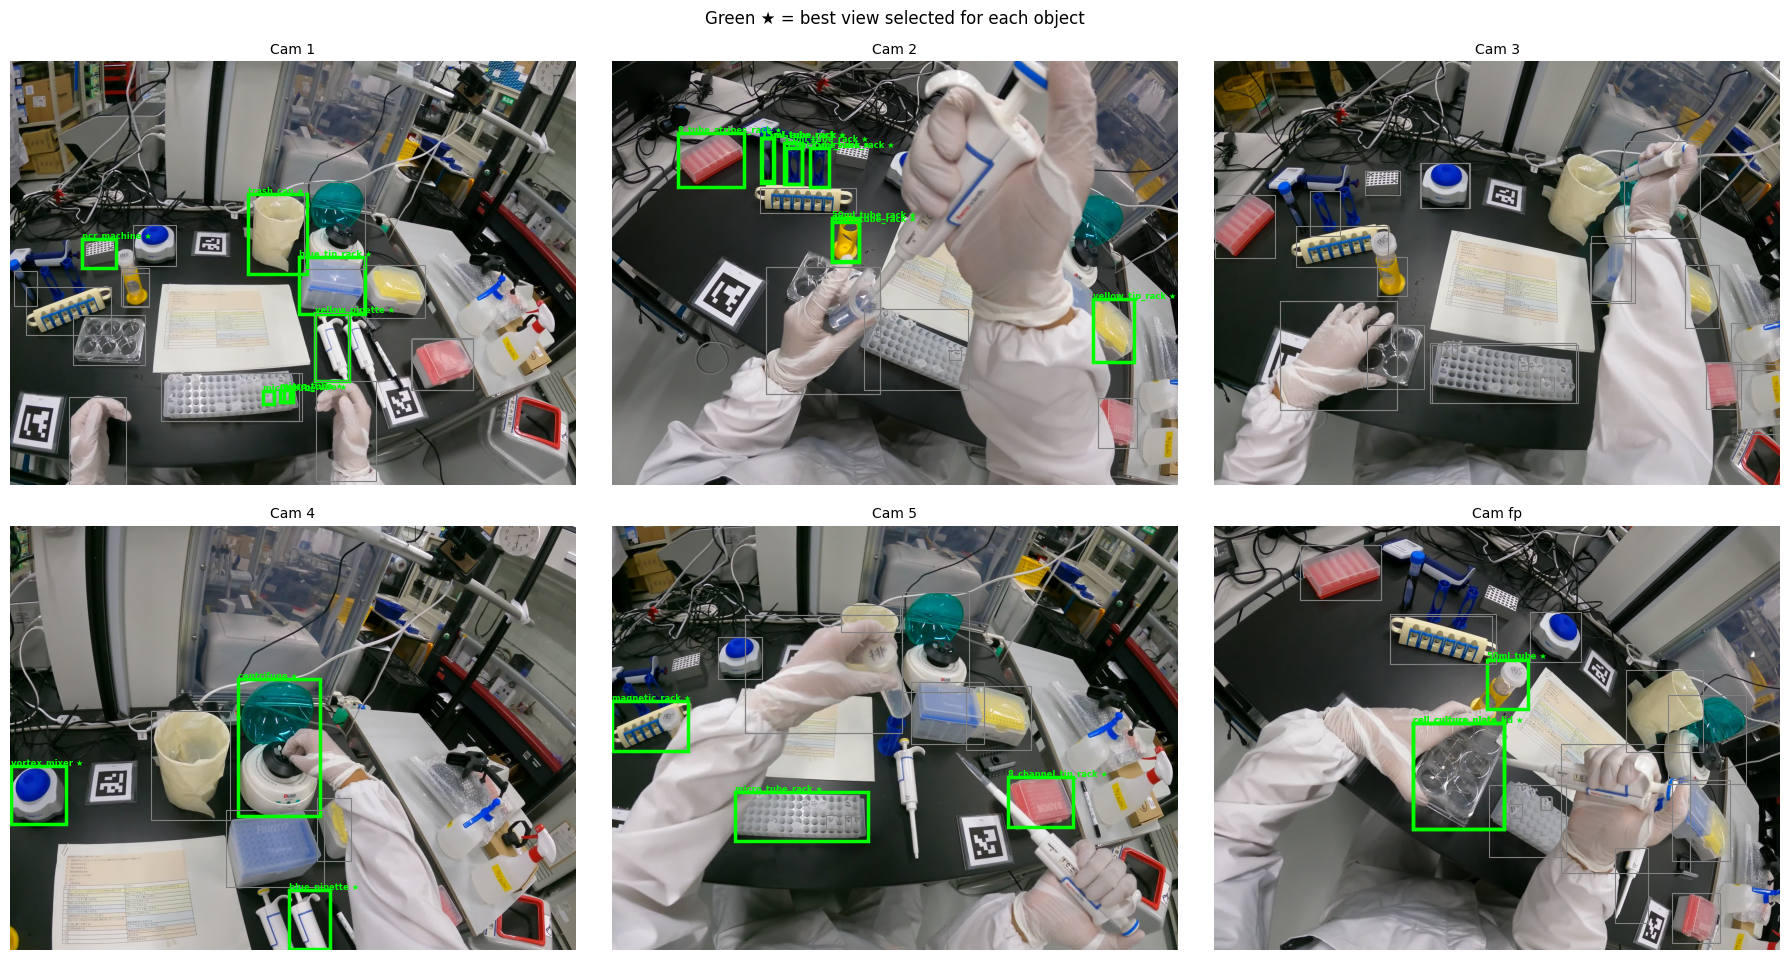

In [14]:
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches

COLORS = {
    1: (0, 200, 100), 2: (0, 100, 255), 3: (255, 150, 0),
    4: (200, 0, 200), 5: (0, 200, 200), "fp": (255, 50, 50),
}

def visualise_best_views(frame_paths, best_views, all_detections, cat_names):
    n_cams = len(frame_paths)
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()

    for ax, (cam_id, img_path) in zip(axes, frame_paths.items()):
        img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
        ax.imshow(img)
        dets = all_detections.get(cam_id, [])
        for det in dets:
            x1, y1, x2, y2 = det["bbox_xyxy"]
            cls_id = det["cls_id"]
            # Highlight if this is the best view for this class
            is_best = (cls_id in best_views and best_views[cls_id]["best_cam"] == cam_id)
            color   = "lime" if is_best else "gray"
            lw      = 2.5 if is_best else 0.8
            rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                      linewidth=lw, edgecolor=color, facecolor="none")
            ax.add_patch(rect)
            if is_best:
                ax.text(x1, y1-4, f"{cat_names[cls_id]} ★",
                        color="lime", fontsize=6, fontweight="bold")
        ax.set_title(f"Cam {cam_id}", fontsize=10)
        ax.axis("off")

    plt.suptitle("Green ★ = best view selected for each object", fontsize=12)
    plt.tight_layout()
    plt.show()

visualise_best_views(demo_frame_paths, best_views, all_detections, cat_names)

## 7. Lightweight triangulation
For each object, triangulate 3D position from the 2 best-scoring views using DLT.
We don't need full reconstruction — just approximate 3D centroid per object.

In [16]:
import numpy as np
import cv2

def undistort_point(pt, K, dist):
    """Undistort a single 2D point using camera intrinsics."""
    pts = np.array([[pt]], dtype=np.float64)
    undist = cv2.undistortPoints(pts, K, dist, P=K)
    return undist[0][0]


def triangulate_point(pt1, K1, dist1, P1, pt2, K2, dist2, P2):
    """
    Triangulate a single 3D point from two 2D observations.
    Uses OpenCV's triangulatePoints (DLT) — fast and good enough for
    approximate scene graph positions.
    Returns: (X, Y, Z) in world coordinates (metres if calibration is in metres).
    """
    u1 = undistort_point(pt1, K1, dist1).reshape(2, 1)
    u2 = undistort_point(pt2, K2, dist2).reshape(2, 1)
    pt4d = cv2.triangulatePoints(P1, P2, u1, u2)   # homogeneous 4D
    pt3d = (pt4d[:3] / pt4d[3]).reshape(3)          # dehomogenise
    return pt3d


def triangulate_all_objects(best_views, cameras):
    """
    For each detected object, use the top-2 scoring views to triangulate 3D position.
    Falls back to top-1 view only (no triangulation) if object seen in only 1 view.

    Returns: {
        cls_id: {
            "pos3d"     : np.array([X, Y, Z]) or None,
            "method"    : "triangulated" | "single_view_only",
            "views_used": [cam_id, ...]
        }
    }
    """
    results = {}

    for cls_id, info in best_views.items():
        all_views = info["all_views"]  # sorted by score desc

        if len(all_views) < 2:
            # Only seen in one view — can't triangulate
            results[cls_id] = {
                "pos3d"     : None,
                "method"    : "single_view_only",
                "views_used": [all_views[0][0]],
            }
            continue

        # Take top-2 views
        cam1_id, det1, _ = all_views[0]
        cam2_id, det2, _ = all_views[1]

        cam1 = cameras.get(cam1_id)
        cam2 = cameras.get(cam2_id)

        # Skip first-person camera for triangulation (pose is per-frame, handle separately)
        if cam1 is None or cam2 is None or \
           cam1.get("type") == "first_person" or cam2.get("type") == "first_person":
            results[cls_id] = {
                "pos3d"     : None,
                "method"    : "skipped_fp_cam",
                "views_used": [cam1_id, cam2_id],
            }
            continue

        try:
            pt3d = triangulate_point(
                det1["bbox_center"], cam1["K"], cam1["dist"], cam1["P"],
                det2["bbox_center"], cam2["K"], cam2["dist"], cam2["P"],
            )
            results[cls_id] = {
                "pos3d"     : pt3d,
                "method"    : "triangulated",
                "views_used": [cam1_id, cam2_id],
            }
        except Exception as e:
            results[cls_id] = {
                "pos3d"  : None,
                "method" : f"error: {e}",
                "views_used": [cam1_id, cam2_id],
            }

    return results


positions_3d = triangulate_all_objects(best_views, cameras)

print("3D positions (world coords):")
for cls_id, res in positions_3d.items():
    pos = res["pos3d"]
    pos_str = f"({pos[0]:.3f}, {pos[1]:.3f}, {pos[2]:.3f})" if pos is not None else "N/A"
    print(f"  {cat_names[cls_id]:30s}  {pos_str}  [{res['method']}]  views: {res['views_used']}")

3D positions (world coords):
  yellow_tip_rack                 N/A  [error: OpenCV(4.13.0) /io/opencv/modules/calib3d/src/undistort.dispatch.cpp:362: error: (-215:Assertion failed) CV_IS_MAT(_distCoeffs) && (_distCoeffs->rows == 1 || _distCoeffs->cols == 1) && (_distCoeffs->rows*_distCoeffs->cols == 4 || _distCoeffs->rows*_distCoeffs->cols == 5 || _distCoeffs->rows*_distCoeffs->cols == 8 || _distCoeffs->rows*_distCoeffs->cols == 12 || _distCoeffs->rows*_distCoeffs->cols == 14) in function 'cvUndistortPointsInternal'
]  views: [2, 1]
  blue_tip_rack                   N/A  [error: OpenCV(4.13.0) /io/opencv/modules/calib3d/src/undistort.dispatch.cpp:362: error: (-215:Assertion failed) CV_IS_MAT(_distCoeffs) && (_distCoeffs->rows == 1 || _distCoeffs->cols == 1) && (_distCoeffs->rows*_distCoeffs->cols == 4 || _distCoeffs->rows*_distCoeffs->cols == 5 || _distCoeffs->rows*_distCoeffs->cols == 8 || _distCoeffs->rows*_distCoeffs->cols == 12 || _distCoeffs->rows*_distCoeffs->cols == 14) in funct

## 8. Reprojection error check
Validate triangulation quality — reproject 3D points back into each view and measure pixel error.

In [17]:
def reprojection_error(pt3d, observed_2d, K, dist, R, t):
    """
    Project pt3d into camera and measure L2 distance from observed_2d.
    Returns pixel error.
    """
    projected, _ = cv2.projectPoints(
        pt3d.reshape(1, 3), R, t, K, dist
    )
    proj_2d = projected[0][0]
    return float(np.linalg.norm(proj_2d - np.array(observed_2d)))


print("Reprojection errors (pixels):")
errors = []
for cls_id, res in positions_3d.items():
    if res["pos3d"] is None or res["method"] != "triangulated":
        continue
    for cam_id, det, _ in best_views[cls_id]["all_views"][:2]:
        cam = cameras.get(cam_id)
        if cam is None or cam.get("type") == "first_person":
            continue
        err = reprojection_error(
            res["pos3d"], det["bbox_center"],
            cam["K"], cam["dist"], cam["R"], cam["t"]
        )
        errors.append(err)
        print(f"  {cat_names[cls_id]:30s}  cam {cam_id}  error: {err:.2f} px")

if errors:
    print(f"\nMean reprojection error: {np.mean(errors):.2f} px")
    print("(< 5px is good; < 10px is acceptable for scene graph purposes)")

Reprojection errors (pixels):


## 9. Visualise 3D positions (top-down bench view)

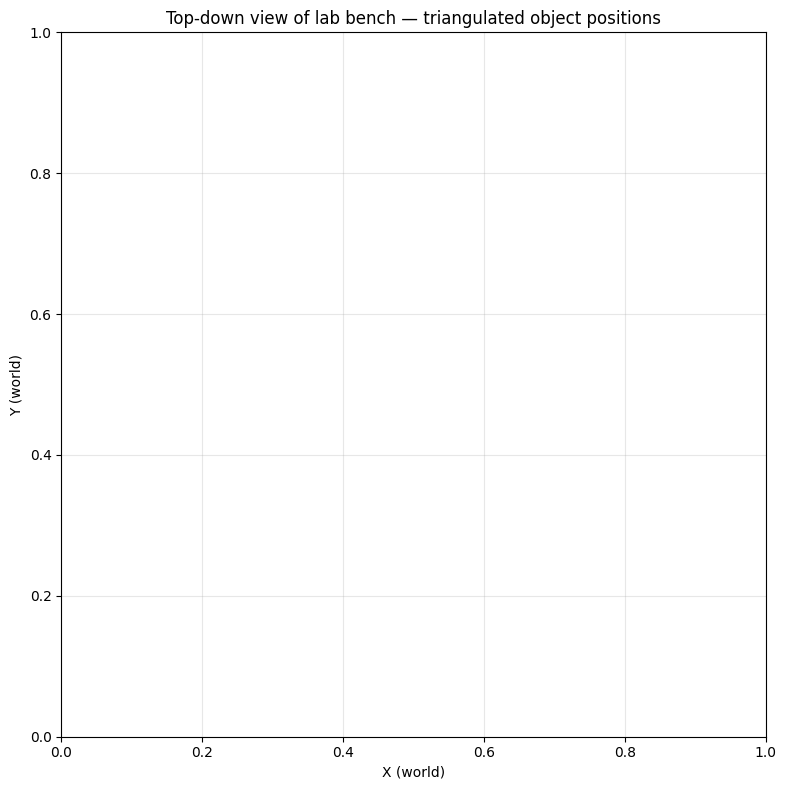

In [18]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(10, 8))

for cls_id, res in positions_3d.items():
    if res["pos3d"] is None:
        continue
    x, y, z = res["pos3d"]
    ax.scatter(x, y, s=80, zorder=3)
    ax.annotate(cat_names[cls_id], (x, y), fontsize=7, ha="center", va="bottom")

ax.set_xlabel("X (world)")
ax.set_ylabel("Y (world)")
ax.set_title("Top-down view of lab bench — triangulated object positions")
ax.set_aspect("equal")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Package output for scene graph
Save per-frame object positions as JSON — input to the next notebook.

In [19]:
import json

def package_frame_state(frame_id, positions_3d, best_views, cat_names):
    """
    Serialise one frame's object positions and best-view detections.
    """
    objects = {}
    for cls_id, res in positions_3d.items():
        bv = best_views[cls_id]
        det = bv["detection"]
        objects[cat_names[cls_id]] = {
            "cls_id"     : cls_id,
            "pos3d"      : res["pos3d"].tolist() if res["pos3d"] is not None else None,
            "method"     : res["method"],
            "best_cam"   : bv["best_cam"],
            "conf"       : det["conf"],
            "bbox_xyxy"  : det["bbox_xyxy"],
            "bbox_center": det["bbox_center"],
        }
    return {"frame_id": frame_id, "objects": objects}


# Example for a single frame — in practice loop over all frames
frame_state = package_frame_state(
    frame_id   = 100,
    positions_3d = positions_3d,
    best_views = best_views,
    cat_names  = cat_names,
)

output_path = Path("./finebio_frame_states.json")
with open(output_path, "w") as f:
    json.dump([frame_state], f, indent=2)

print(f"Frame state saved to {output_path}")
print(json.dumps(frame_state, indent=2)[:800], "...")

Frame state saved to finebio_frame_states.json
{
  "frame_id": 100,
  "objects": {
    "yellow_tip_rack": {
      "cls_id": 11,
      "pos3d": null,
      "method": "error: OpenCV(4.13.0) /io/opencv/modules/calib3d/src/undistort.dispatch.cpp:362: error: (-215:Assertion failed) CV_IS_MAT(_distCoeffs) && (_distCoeffs->rows == 1 || _distCoeffs->cols == 1) && (_distCoeffs->rows*_distCoeffs->cols == 4 || _distCoeffs->rows*_distCoeffs->cols == 5 || _distCoeffs->rows*_distCoeffs->cols == 8 || _distCoeffs->rows*_distCoeffs->cols == 12 || _distCoeffs->rows*_distCoeffs->cols == 14) in function 'cvUndistortPointsInternal'\n",
      "best_cam": 2,
      "conf": 0.9858129620552063,
      "bbox_xyxy": [
        1630.0352783203125,
        806.4336547851562,
        1769.498291015625,
        1021.8409423828125
      ],
      "bbox_center": [
        ...


## 11. Next steps
The output of this notebook — `finebio_frame_states.json` — feeds directly into:
- **Scene graph construction**: persistent object state tracker across frames
- **Contact detection**: MediaPipe fingertip proximity to object bboxes in best view
- **Graph transition detection**: atomic operations as detected state changes